# 02 - Pré-processamento da Base Spotify

## Projeto Integrador - Music Selector

Este notebook documenta a etapa de pré-processamento da base de músicas do Spotify utilizada no projeto **Music Selector**.

Objetivo da etapa:

- carregar a base com a coluna `vibe`;
- analisar estrutura, nulos e duplicados;
- remover atributos irrelevantes;
- analisar estatísticas e outliers;
- verificar distribuição das classes;
- balancear a base;
- normalizar variáveis numéricas;
- salvar a base final pré-processada.

A coluna `vibe` foi criada previamente por regras heurísticas com base em atributos musicais como `energy`, `danceability`, `valence`, `acousticness`, `instrumentalness`, `speechiness` e `tempo`.


## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

## 2. Carregamento da base

A base carregada é o arquivo `clean_with_vibe_full.csv`, gerado pelo pipeline de criação de labels.

Esse arquivo contém os dados musicais do Spotify e a coluna alvo `vibe`.


In [2]:
df = pd.read_csv("../data/dataset_final.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,vibe
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,party
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,relax
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,relax
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,relax
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,relax


## 3. Análise inicial da estrutura da base

In [3]:
print("Tamanho da base:")
print(df.shape)

print("\nColunas presentes na base:")
print(df.columns.tolist())

Tamanho da base:
(114000, 22)

Colunas presentes na base:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'vibe']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

### Justificativa

A análise inicial permite compreender a quantidade de registros, atributos, tipos de dados e possíveis problemas estruturais da base antes das transformações.


## 4. Verificação de valores ausentes

In [5]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
vibe                0
dtype: int64

### Justificativa

Valores ausentes podem prejudicar o treinamento dos modelos. Nesta base, os poucos valores ausentes aparecem em campos textuais, como `artists`, `album_name` e `track_name`, que não serão usados diretamente no treinamento.


## 5. Verificação de registros duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

### Justificativa

A verificação de duplicatas evita que registros repetidos influenciem indevidamente o aprendizado do modelo.


## 6. Remoção de atributos irrelevantes

In [7]:
colunas_remover = [
    "Unnamed: 0",
    "track_id",
    "track_name",
    "artists",
    "album_name",
    "track_genre"
]

df_modelo = df.drop(columns=colunas_remover, errors="ignore")
df_modelo.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,vibe
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,party
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,relax
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,relax
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,relax
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,relax


### Justificativa

Foram removidas colunas identificadoras ou textuais que não contribuem diretamente para o treinamento numérico:

- `track_id`: identificador único;
- `track_name`: nome da música;
- `artists`: nome dos artistas;
- `album_name`: nome do álbum;
- `track_genre`: categoria textual;
- `Unnamed: 0`: índice importado do CSV.

Esses campos poderiam gerar ruído ou exigiriam tratamento textual adicional.


## 7. Estatísticas descritivas

In [8]:
df_modelo.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Justificativa

As estatísticas descritivas permitem observar média, desvio padrão, valores mínimos e máximos das variáveis numéricas.


## 8. Seleção das variáveis numéricas

In [9]:
variaveis_numericas = df_modelo.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
variaveis_numericas

['popularity',
 'duration_ms',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

## 9. Análise de outliers

A análise de outliers foi feita com boxplots das variáveis numéricas. Outliers são valores muito distantes do padrão geral, mas em dados musicais podem representar faixas reais, como músicas muito longas, rápidas, lentas, instrumentais ou acústicas.


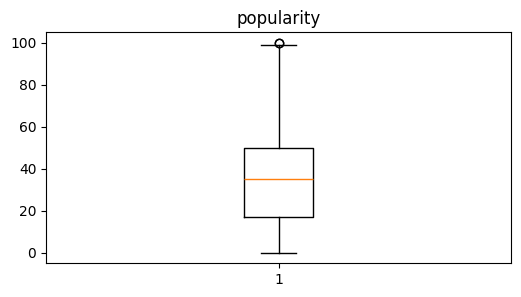

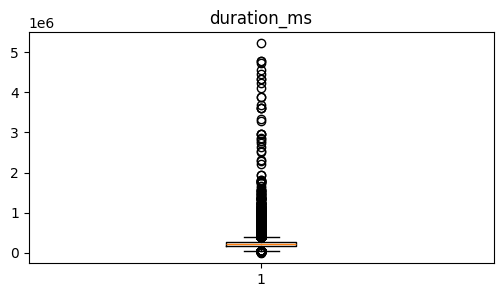

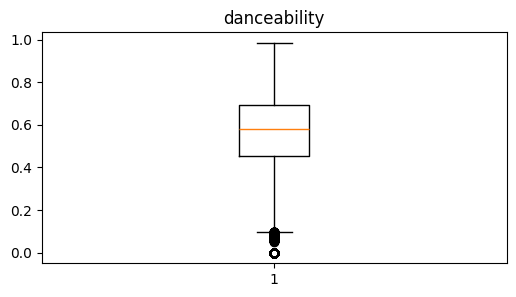

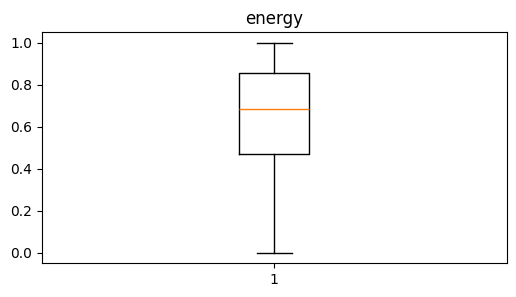

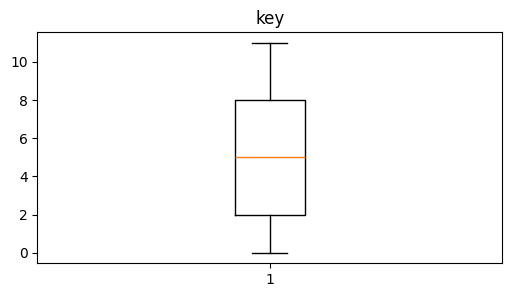

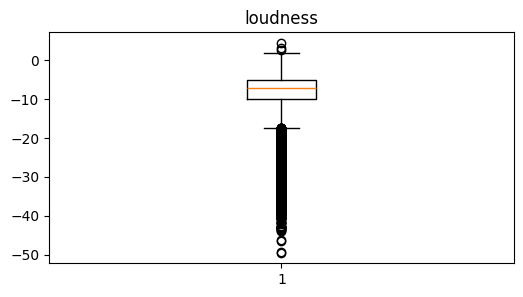

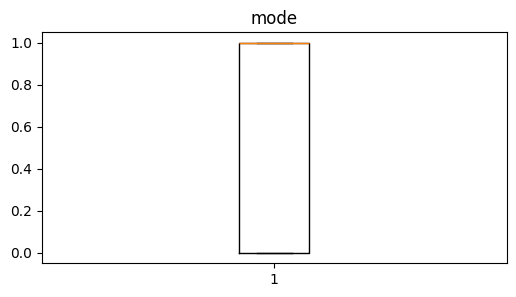

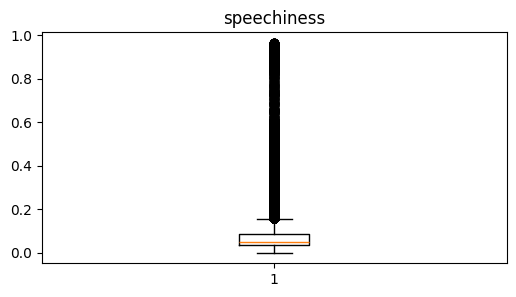

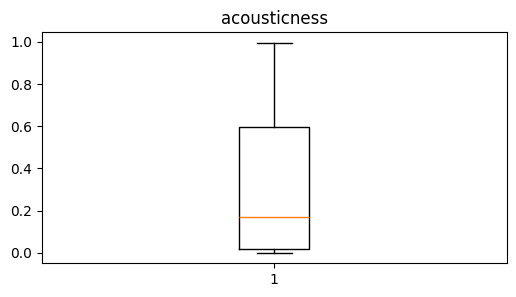

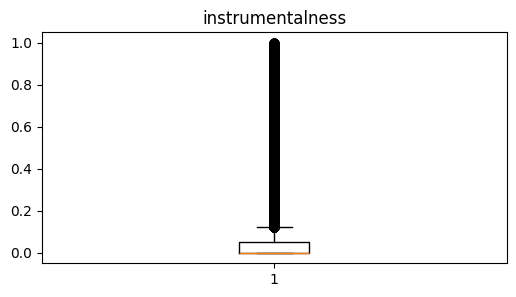

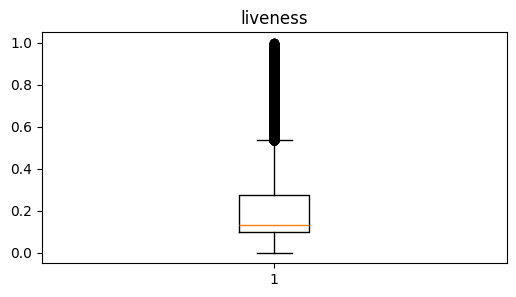

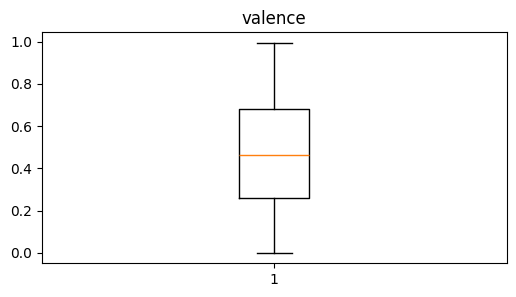

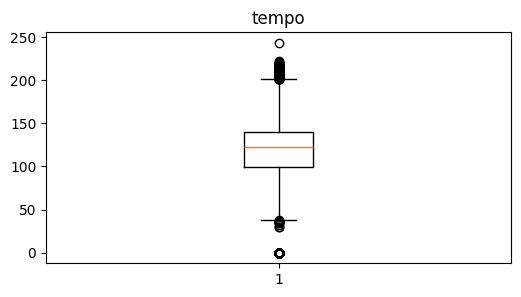

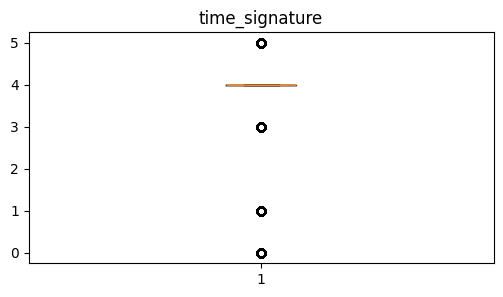

In [10]:
for coluna in variaveis_numericas:
    plt.figure(figsize=(6,3))
    plt.boxplot(df_modelo[coluna])
    plt.title(coluna)
    plt.show()

### Análise dos Outliers:
A análise por meio de boxplots identificou valores extremos em algumas variáveis, principalmente duration_ms, loudness, speechiness, instrumentalness, liveness e tempo. Após avaliação, concluiu-se que esses valores representam características musicais legítimas (músicas mais longas, instrumentais, gravações ao vivo ou com BPM elevado) e não erros nos dados. Dessa forma, optou-se por manter os registros no conjunto de dados para preservar a diversidade das informações disponíveis para o treinamento dos modelos.

## 10. Distribuição original da variável alvo `vibe`

In [11]:
df_modelo["vibe"].value_counts()

vibe
workout     65679
relax       20844
party       18250
focus        4774
romantic     3863
chill         590
Name: count, dtype: int64

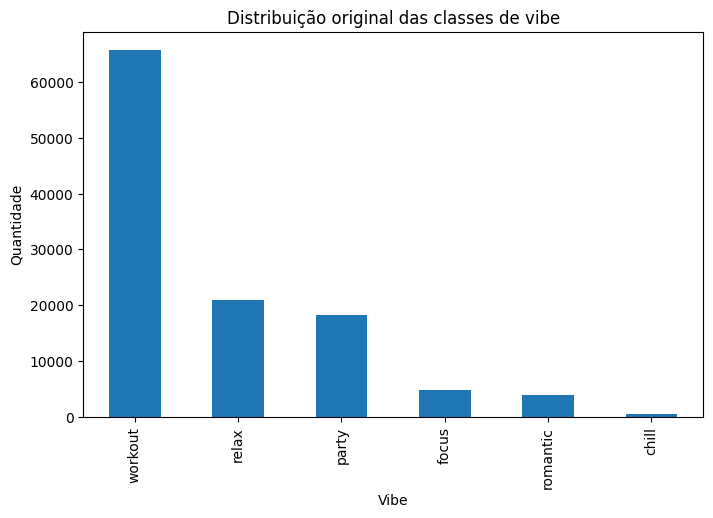

In [13]:
df_modelo["vibe"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Distribuição original das classes de vibe")
plt.xlabel("Vibe")
plt.ylabel("Quantidade")
plt.show()

### Justificativa

A análise da variável alvo é essencial em problemas de classificação. Foi identificado desbalanceamento entre as classes, principalmente com predominância da classe `workout` e menor quantidade de registros da classe `chill`.


## 11. Balanceamento da base

In [12]:
N = 3000
partes = []

for nome_vibe in df_modelo["vibe"].unique():
    grupo = df_modelo[df_modelo["vibe"] == nome_vibe]
    amostra = grupo.sample(
        n=min(len(grupo), N),
        random_state=42
    )
    partes.append(amostra)

df_balanced = pd.concat(partes, ignore_index=True)
df_balanced["vibe"].value_counts()

vibe
party       3000
relax       3000
workout     3000
romantic    3000
focus       3000
chill        590
Name: count, dtype: int64

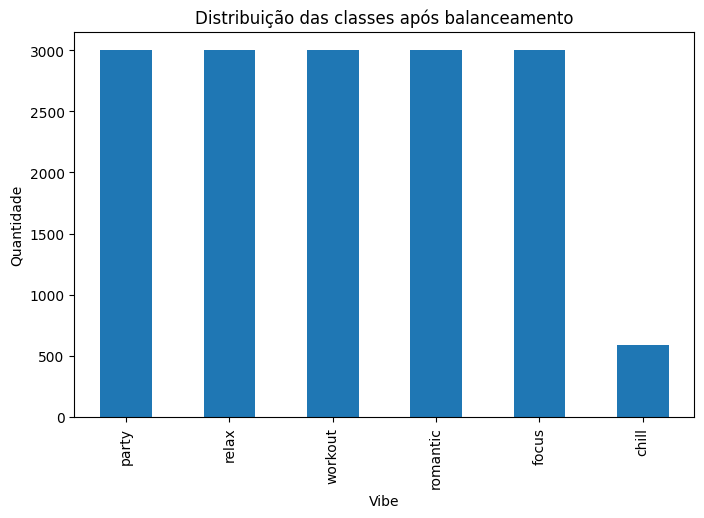

In [15]:
df_balanced["vibe"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Distribuição das classes após balanceamento")
plt.xlabel("Vibe")
plt.ylabel("Quantidade")
plt.show()

### Justificativa

Foi aplicado balanceamento por amostragem, limitando cada classe a no máximo 3000 registros. A classe `chill` foi mantida com todos os registros disponíveis, por possuir menos exemplos.

Esse procedimento reduz o impacto das classes majoritárias no treinamento.


## 12. Separação entre atributos e classe alvo

In [13]:
X = df_balanced.drop(columns=["vibe"], errors="ignore")
y = df_balanced["vibe"]

X = X.select_dtypes(include=["int64", "float64", "bool"])

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

X.head()

Formato de X: (15590, 15)
Formato de y: (15590,)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,59,219240,False,0.833,0.639,5,-6.964,1,0.0676,0.152000,0.000000,0.1010,0.4480,102.989,4
1,30,579925,True,0.595,0.806,2,-5.732,1,0.9370,0.729000,0.000000,0.8730,0.4490,82.933,4
2,80,205090,True,0.731,0.573,4,-10.059,0,0.0544,0.401000,0.000052,0.1130,0.1450,109.928,4
3,7,407680,False,0.806,0.576,1,-12.158,0,0.0512,0.000163,0.862000,0.0927,0.0518,122.970,4
4,0,191533,False,0.863,0.624,3,-5.637,1,0.0375,0.540000,0.000008,0.0300,0.9580,105.490,4


### Justificativa

A variável `vibe` foi separada como classe alvo, enquanto as variáveis numéricas foram mantidas como atributos de entrada para o modelo.


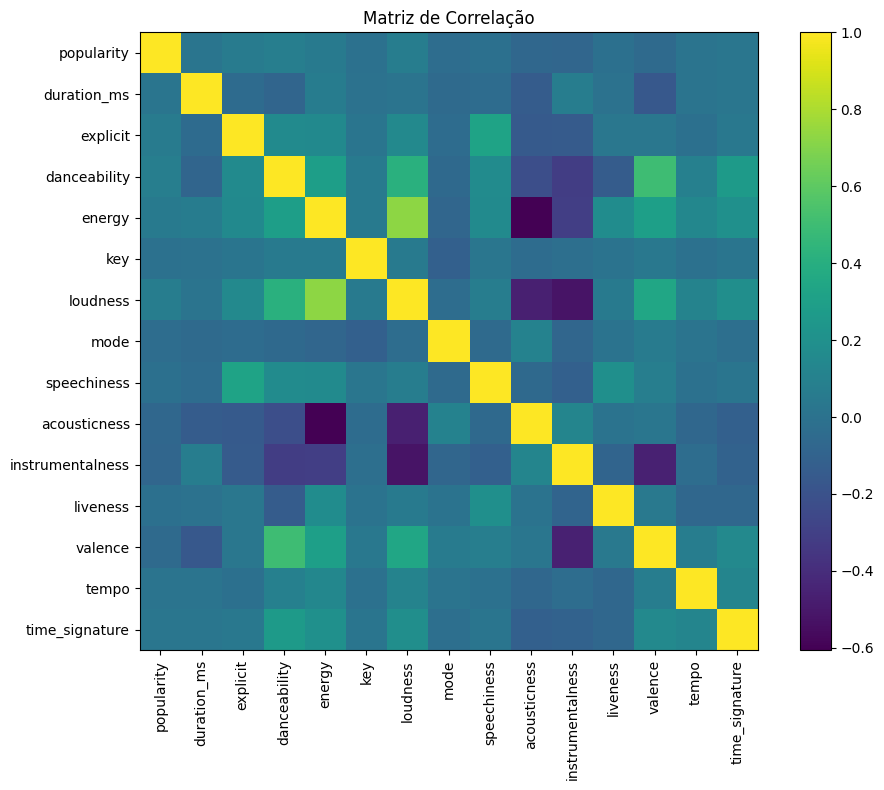

In [17]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

## 13. Normalização das variáveis numéricas

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,1.232860,-0.002788,-0.261941,1.430668,0.547028,-0.063543,0.616723,0.729718,-0.093699,-0.960111,-0.663054,-0.561175,-0.133220,-0.283163,0.264004
1,-0.098954,2.857931,3.817647,0.203648,1.247035,-0.913879,0.831657,0.729718,8.543388,0.725740,-0.663054,3.552815,-0.129700,-0.960295,0.264004
2,2.197277,-0.115017,3.817647,0.904802,0.270378,-0.346989,0.076772,-1.370393,-0.224835,-0.232595,-0.662919,-0.497227,-1.199945,-0.048888,0.264004
3,-1.155221,1.491796,-0.261941,1.291468,0.282953,-1.197324,-0.289418,-1.370393,-0.256626,-1.403741,1.567100,-0.605406,-1.528060,0.391436,0.264004
4,-1.476693,-0.222542,-0.261941,1.585334,0.484153,-0.630434,0.848231,0.729718,-0.392729,0.173529,-0.663032,-0.939534,1.662256,-0.198724,0.264004


### Justificativa

A normalização padroniza as variáveis numéricas para média próxima de 0 e desvio padrão próximo de 1.

Isso é importante porque os atributos possuem escalas diferentes. Por exemplo, `duration_ms` possui valores muito maiores do que atributos como `danceability`, `energy` e `valence`, que variam entre 0 e 1.


## 14. Salvamento da base pré-processada

In [16]:
df_balanced.to_csv("../data/dataset_treino_balanceado.csv", index=False)

print("Arquivo salvo em: data/dataset_treino_balanceado.csv")

Arquivo salvo em: data/dataset_treino_balanceado.csv


## 15. Conclusão

Nesta etapa, a base foi preparada para aplicação de algoritmos de Machine Learning.

Foram realizados:

- carregamento da base rotulada;
- análise estrutural;
- verificação de valores ausentes;
- verificação de duplicatas;
- remoção de atributos irrelevantes;
- estatísticas descritivas;
- análise de outliers;
- análise da distribuição das classes;
- balanceamento;
- separação entre atributos e classe alvo;
- normalização;
- salvamento da base final.

A base resultante será usada na etapa seguinte de treinamento e avaliação dos modelos.
